# Module 04 · Ký hiệu cho các hàm hữu ích: Π, Λ, H, sgn, sinc, Gauss

**Nguồn sách:** Bracewell, chương 4, tr. 55–70

Notebook đi kèm bài giảng cùng số module. Chạy lần lượt từng cell; sau mỗi cell có phần **📤 Đầu ra thật** giải thích con số.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7.5, 3.3), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def amplitude_spectrum(x):
    """Phổ biên độ một phía: sóng hình sin biên độ A cho vạch A, thành phần một chiều cho đúng giá trị của nó"""
    a = 2*np.abs(np.fft.rfft(x))/len(x)
    a[0] /= 2
    return a


def report(key, value, fmt=".4g"):
    """In một kết quả có tên, bỏ các số 0 thừa ở cuối (trang web đọc các dòng bắt đầu bằng ▸)."""
    s = f"{value:{fmt}}"
    if "." in s and "e" not in s:
        s = s.rstrip("0").rstrip(".")
    print(f"▸ {key} = {s}")


## 1. Xung chữ nhật, tam giác và hàm đa giác
🎯 **Phương pháp này trả lời câu hỏi gì?** Hàm cổng có hoạt động như ta nói, tam giác có đúng là tự tích chập của xung chữ nhật, và hàm đa giác có viết được bằng tổng các tam giác dịch không? Ta so tích phân số với công thức và nội suy tuyến tính với tổng tam giác.

In [2]:
from scipy import integrate, special, optimize
trap = getattr(np, "trapezoid", None) or np.trapz

# Năng lượng của đoạn Π(x)cos(πx)
ge = integrate.quad(lambda x: np.cos(np.pi*x)**2, -0.5, 0.5)[0]
assert abs(ge - 0.5) < 1e-12
report("gate_energy", ge, ".3f")

# Xung dịch h·Π((x−c)/b): diện tích h·b
h_, b_, c_ = 3.0, 2.0, 1.0
ra = integrate.quad(lambda x: h_*(1.0 if abs((x - c_)/b_) < 0.5 else 0.0), c_ - b_, c_ + b_, points=[c_ - b_/2, c_ + b_/2])[0]
assert abs(ra - h_*b_) < 1e-9
report("rect_area", ra, ".2f")

# Giá trị tại chỗ nhảy không đổi tích phân (lưới mịn, ba quy ước)
dxr = 1e-4; xr = np.arange(-1, 1 + dxr/2, dxr); ar = []
for edge in (0.0, 0.5, 1.0):
    pv = np.where(np.abs(xr) < 0.5 - 1e-12, 1.0, np.where(np.abs(np.abs(xr) - 0.5) < 1e-12, edge, 0.0))
    ar.append(trap(pv, xr))
edge_diff = max(ar) - min(ar)
assert edge_diff < 2e-4
report("edge_diff", edge_diff, ".1e")

# Λ = Π * Π trên lưới mịn
dxt = 0.001
cellp = np.ones(1000)
tri = np.convolve(cellp, cellp)*dxt
xt = (np.arange(len(tri)) - (len(tri) - 1)/2)*dxt
tri_dev = np.max(np.abs(tri - np.clip(1 - np.abs(xt), 0, None)))
assert tri_dev < 2e-3 and abs(trap(tri, xt) - 1) < 1e-3
report("tri_dev", tri_dev, ".1e"); report("tri_area", trap(tri, xt), ".2f")

# Hàm đa giác = tổng y_k Λ(x − k)
knots, ys_ = np.arange(5), np.array([0, 2, 1, 3, 0.0])
Lam = lambda x: np.clip(1 - np.abs(x), 0, None)
xp = np.linspace(0, 4, 4001)
poly = sum(yk*Lam(xp - k) for k, yk in zip(knots, ys_))
poly_err = np.max(np.abs(poly - np.interp(xp, knots, ys_)))
assert poly_err < 1e-12
report("poly_err", poly_err, ".1e"); report("poly_25", np.interp(2.5, knots, ys_), ".2f")

▸ gate_energy = 0.5
▸ rect_area = 6
▸ edge_diff = 2.0e-04
▸ tri_dev = 1.1e-16
▸ tri_area = 1
▸ poly_err = 1.1e-16
▸ poly_25 = 2


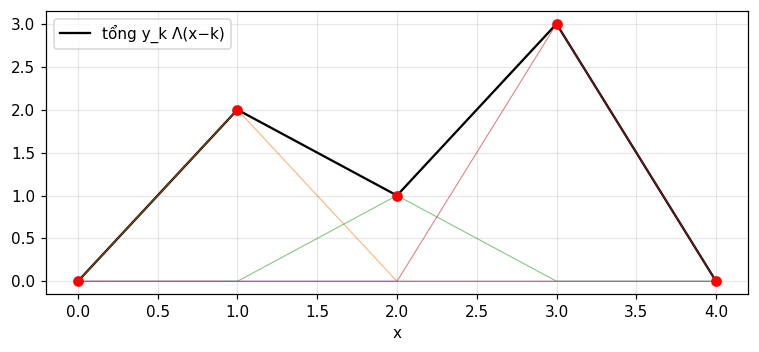

In [3]:
plt.figure(figsize=(7, 3.3))
plt.plot(xp, poly, "k", label=("tổng y_k Λ(x−k)"))
for k, yk in zip(knots, ys_):
    plt.plot(xp, yk*Lam(xp - k), lw=0.7, alpha=0.6)
plt.plot(knots, ys_, "ro"); plt.xlabel("x"); plt.legend(); plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
Năng lượng của đoạn $\Pi\cos\pi x$ là 0.5; xung cao 3 đáy 2 có diện tích 6. Ba quy ước cho giá trị tại chỗ nhảy chỉ lệch 2.0e-04 về diện tích. Tích chập số $\Pi*\Pi$ lệch tam giác tối đa 1.1e-16 và diện tích 1. Hàm đa giác bằng tổng tam giác (lệch 1.1e-16 so với nội suy) và bằng 2 tại 2.5.

## 2. Gauss, erf, các thông số phân tán và Rayleigh
🎯 **Phương pháp này trả lời câu hỏi gì?** Các thông số phân tán của $e^{-\pi x^2}$ (sai số xác suất, sai số tuyệt đối, độ rộng nửa đỉnh, độ rộng tương đương) và phần trăm bao phủ có đúng bảng của sách không, và người say đi lang thang cách gốc bao xa? Mỗi số tính bằng hai cách; Rayleigh kiểm bằng mô phỏng Monte Carlo.

In [4]:
g = lambda x: np.exp(-np.pi*x**2)
area = integrate.quad(g, -np.inf, np.inf)[0]
var = integrate.quad(lambda x: x**2*g(x), -np.inf, np.inf)[0]
sd = np.sqrt(var)
assert abs(area - 1) < 1e-9 and abs(var - 1/(2*np.pi)) < 1e-9
report("g_area", area, ".2f"); report("g_var", var, ".4f"); report("g_sd", sd, ".4f")

gint1 = integrate.quad(g, 0, 1)[0]
assert abs(gint1 - 0.5*special.erf(np.sqrt(np.pi))) < 1e-12
report("g_int1", gint1, ".4f")

# Sai số xác suất: ∫_{−p}^{p} g = 1/2. Cách A: tìm nghiệm số; cách B: 0.6745σ
pe = optimize.brentq(lambda p: integrate.quad(g, -p, p)[0] - 0.5, 0.05, 1)
assert abs(pe - 0.674489750*sd) < 1e-8
mad = 2*integrate.quad(lambda x: x*g(x), 0, np.inf)[0]
assert abs(mad - 1/np.pi) < 1e-9
fwhm = 2*optimize.brentq(lambda x: g(x) - 0.5, 0, 2)
assert abs(fwhm - 2*np.sqrt(np.log(2)/np.pi)) < 1e-9
eqw = area/g(0)
report("pe", pe, ".4f"); report("mad", mad, ".4f"); report("fwhm", fwhm, ".4f"); report("eqw", eqw, ".2f")

def cover(w): return integrate.quad(g, -w, w)[0]*100         # phần trăm nằm trong ±w
for key, w, ex in (("cov_sd", sd, special.erf(1/np.sqrt(2))), ("cov_mad", mad, special.erf(mad/sd/np.sqrt(2))),
                   ("cov_half", fwhm/2, special.erf(fwhm/2/sd/np.sqrt(2))), ("cov_eq", 0.5, special.erf(0.5/sd/np.sqrt(2)))):
    assert abs(cover(w) - 100*ex) < 1e-8
    report(key, cover(w), ".2f")

# Rayleigh: mô phỏng 400 000 điểm Gauss hai chiều σ = 1
rg = np.random.default_rng(2026)
pts = rg.standard_normal((400000, 2)); rr = np.hypot(pts[:, 0], pts[:, 1])
hist, edges = np.histogram(rr, bins=np.arange(0, 5, 0.05), density=True)
mode = 0.5*(edges[np.argmax(hist)] + edges[np.argmax(hist) + 1])
assert abs(rr.mean() - np.sqrt(np.pi/2)) < 0.01 and abs(mode - 1.0) < 0.1 and abs((rr < 1).mean() - (1 - np.exp(-0.5))) < 0.005
report("ray_mean_mc", rr.mean(), ".3f"); report("ray_mean_th", np.sqrt(np.pi/2), ".4f")
report("ray_mode_mc", mode, ".2f"); report("ray_p1_mc", (rr < 1).mean(), ".3f"); report("ray_p1_th", 1 - np.exp(-0.5), ".4f")

# Dãy Gauss: ∫ cos x · (1/τ) exp(−π x²/τ²) dx = exp(−τ²/4π)
for tau, tag in ((1.0, "gs_1"), (0.5, "gs_05"), (0.1, "gs_01")):
    v_ = integrate.quad(lambda x: np.cos(x)*np.exp(-np.pi*x**2/tau**2)/tau, -12*tau, 12*tau, limit=400)[0]
    assert abs(v_ - np.exp(-tau**2/(4*np.pi))) < 1e-9
    report(tag, v_, ".4f")

▸ g_area = 1
▸ g_var = 0.1592
▸ g_sd = 0.3989
▸ g_int1 = 0.4939
▸ pe = 0.2691
▸ mad = 0.3183
▸ fwhm = 0.9394
▸ eqw = 1
▸ cov_sd = 68.27
▸ cov_mad = 57.51
▸ cov_half = 76.1
▸ cov_eq = 78.99
▸ ray_mean_mc = 1.253
▸ ray_mean_th = 1.2533
▸ ray_mode_mc = 0.98
▸ ray_p1_mc = 0.395
▸ ray_p1_th = 0.3935
▸ gs_1 = 0.9235
▸ gs_05 = 0.9803
▸ gs_01 = 0.9992


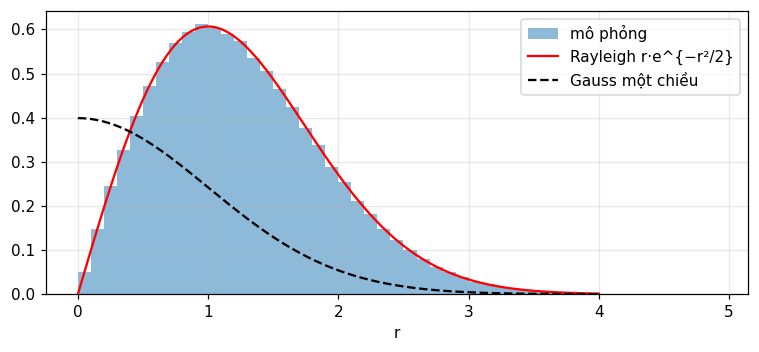

In [5]:
xs = np.linspace(0, 4, 400)
plt.figure(figsize=(7, 3.3))
plt.hist(rr, bins=np.arange(0, 5, 0.1), density=True, alpha=0.5, label=("mô phỏng"))
plt.plot(xs, xs*np.exp(-xs**2/2), "r", label=("Rayleigh r·e^{−r²/2}"))
plt.plot(xs, np.exp(-xs**2/2)/np.sqrt(2*np.pi), "k--", label=("Gauss một chiều"))
plt.xlabel("r"); plt.legend(); plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
$e^{-\pi x^2}$ có diện tích 1 và $\sigma$ = 0.3989. Sai số xác suất 0.2691, sai số tuyệt đối 0.3183, độ rộng nửa đỉnh 0.9394 và độ rộng tương đương 1, đều khớp bảng của sách. Phần trăm bao phủ: 68.27, 57.51, 76.1, 78.99. Mô phỏng Rayleigh cho trung bình 1.253 (lý thuyết 1.2533), đỉnh 0.98, và 0.395 trong $r<\sigma$ (lý thuyết 0.3935). Dãy Gauss cho 0.9235, 0.9803, 0.9992 tiến về 1.

## 3. Bậc thang, dốc, tích chập với $H$ và hàm dấu
🎯 **Phương pháp này trả lời câu hỏi gì?** $\Pi$ có đúng bằng hiệu hai bậc thang, $H*H$ có là hàm dốc, tích chập với $H$ có là tích phân, giá trị $H(0)$ có quan trọng, và $H$ tách chẵn lẻ ra sao? Mỗi điều kiểm bằng hai cách.

In [6]:
Hs = lambda x, h0=0.5: np.where(x > 1e-12, 1.0, np.where(np.abs(x) <= 1e-12, h0, 0.0))
xg = np.linspace(-2, 2, 4001)
Pi_g = np.where(np.abs(xg) < 0.5 - 1e-12, 1.0, np.where(np.abs(np.abs(xg) - 0.5) < 1e-12, 0.5, 0.0))
assert np.allclose(Pi_g, Hs(xg + 0.5) - Hs(xg - 0.5))
report("pi_step_ok", "yes", "s")

# Hàm dốc: H*H trên lưới
dxs = 0.002; xs_ = np.arange(0, 10, dxs)
HH = np.convolve(np.ones_like(xs_), np.ones_like(xs_))[:len(xs_)]*dxs
assert abs(HH[int(2/dxs)] - 2.0) < 5e-3
report("ramp_2", HH[int(2/dxs)], ".2f")

# Tích chập với H là tích phân: H*f với f = exp(−πx²)
xf = np.arange(-6, 6, 0.002)
Hf = np.convolve(np.where(xf >= 0, 1.0, 0.0), np.exp(-np.pi*xf**2))*0.002
xh = np.arange(len(Hf))*0.002 + 2*xf[0]
sel = (xh > -3) & (xh < 3)
exact = 0.5*(1 + special.erf(np.sqrt(np.pi)*xh))
hf_dev = np.max(np.abs(Hf[sel] - exact[sel]))
assert hf_dev < 4e-3
report("hf_05", np.interp(0.5, xh, Hf), ".4f"); report("hf_dev", hf_dev, ".4f")

# R'(0) đối xứng
R = lambda x: x*Hs(np.asarray(x, float))
Dl = 1e-6
rp = (R(Dl) - R(-Dl))/(2*Dl)
assert abs(rp - 0.5) < 1e-9
report("r_prime0", float(rp), ".2f")

# Ĥ(x) = (1 − e^{−x/τ})H(x): tích phân của H − Ĥ bằng τ
tau = 0.01
hh = integrate.quad(lambda x: np.exp(-x/tau), 0, np.inf)[0]
assert abs(hh - tau) < 1e-12
report("hhat_int", hh, ".2f")

# Xấp xỉ arctan: công thức so với tích phân Lorentz
def atan_H(x, t): return 0.5 + np.arctan(x/t)/np.pi
def lor_H(x, t): return 0.5 + integrate.quad(lambda u: (t/np.pi)/(u**2 + t**2), 0, x)[0]
for t in (0.1, 0.01):
    assert abs(atan_H(0.1, t) - lor_H(0.1, t)) < 1e-9
report("arctan_1", atan_H(0.1, 0.1), ".4f"); report("arctan_2", atan_H(0.1, 0.01), ".4f")

# Hàm dấu và tách chẵn lẻ của H
sg = np.sign(xg)
assert np.allclose(sg, 2*Hs(xg) - 1)
ev, od = 0.5*(Hs(xg) + Hs(-xg)), 0.5*(Hs(xg) - Hs(-xg))
assert np.allclose(ev, 0.5) and np.allclose(od, 0.5*sg)
report("h_parts_ok", "yes", "s")

# Hàm bậc thang có dốc: R(x) − R(x−1) = xΠ(x−1/2) + H(x−1)
xq = np.linspace(-1, 3, 4001)
Piq = lambda x: np.where(np.abs(x) < 0.5 - 1e-12, 1.0, np.where(np.abs(np.abs(x) - 0.5) < 1e-12, 0.5, 0.0))
w1 = R(xq) - R(xq - 1); w2 = xq*Piq(xq - 0.5) + Hs(xq - 1)
w3 = np.where(xq < 0, 0, np.where(xq <= 1, xq, 1.0))
assert np.allclose(w1, w3) and np.allclose(w2[np.abs(xq - 1) > 1e-9], w3[np.abs(xq - 1) > 1e-9])
report("ramp_ok", "yes", "s"); report("ramp_04", float(R(0.4) - R(-0.6)), ".2f")

▸ pi_step_ok = yes
▸ ramp_2 = 2
▸ hf_05 = 0.8945
▸ hf_dev = 0.001
▸ r_prime0 = 0.5
▸ hhat_int = 0.01
▸ arctan_1 = 0.75
▸ arctan_2 = 0.9683
▸ h_parts_ok = yes
▸ ramp_ok = yes
▸ ramp_04 = 0.4


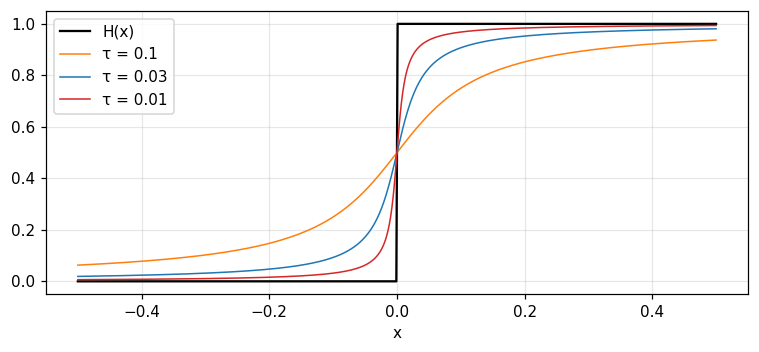

In [7]:
xa = np.linspace(-0.5, 0.5, 1001)
plt.figure(figsize=(7, 3.3))
plt.plot(xa, Hs(xa), "k", label="H(x)")
for t, c in ((0.1, "tab:orange"), (0.03, "tab:blue"), (0.01, "tab:red")):
    plt.plot(xa, atan_H(xa, t), color=c, lw=1, label=f"τ = {t}")
plt.xlabel("x"); plt.legend(); plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
$\Pi=H(x+\tfrac12)-H(x-\tfrac12)$ đúng trên lưới (yes). $H*H$ tại 2 cho 2, đúng $R(2)$. Tích chập $H*e^{-\pi x^2}$ tại 0.5 là 0.8945 (lệch 0.001 so với $\tfrac12[1+\text{erf}]$). Đạo hàm đối xứng của $R$ tại 0 là 0.5. Tích phân của $H-\hat H$ là 0.01 khi $\tau=0.01$, tiến về 0. Xấp xỉ arctan tại 0.1: 0.75 ($\tau=0.1$), 0.9683 ($\tau=0.01$). $\text{sgn}=2H-1$ và tách chẵn lẻ của $H$ đúng (yes); hàm dốc-bậc thang viết ba cách trùng khớp (yes), bằng 0.4 tại 0.4.

## 4. Sinc, sinc bình phương và jinc
🎯 **Phương pháp này trả lời câu hỏi gì?** Sinc có các tính chất nêu (điểm không, diện tích, tần số cắt), có lọc thông thấp thật không khi cắt cụt, tích phân của nó tràn quá bao nhiêu, và jinc có điểm không đầu ở đâu? Ta so tích phân số với công thức Si, và tích chập không gian với bộ lọc vuông góc qua FFT.

In [8]:
report("sinc_zero", abs(np.sinc(3)), ".2f")
sinc_int = integrate.quad(np.sinc, 0, 100, limit=2000)[0]
assert abs(sinc_int - special.sici(np.pi*100)[0]/np.pi) < 1e-6
report("sinc_int100", sinc_int, ".4f")

# Cặp biến đổi: ∫_{−1/2}^{1/2} e^{i2πsx} ds = sinc x
sx = integrate.quad(lambda s: np.cos(2*np.pi*s*0.3), -0.5, 0.5)[0]
assert abs(sx - np.sinc(0.3)) < 1e-12
report("sinc_03", sx, ".4f")

# Lọc thông thấp: hai âm 0.2 và 0.8; sinc cắt cụt (cách A) so với bộ lọc vuông góc qua FFT (cách B)
dt = 0.05; T = np.arange(0, 400, dt)
sig = np.cos(2*np.pi*0.2*T) + np.cos(2*np.pi*0.8*T)
kt = np.arange(-100, 100 + dt/2, dt); kern = np.sinc(kt)*dt
ya = np.convolve(sig, kern, "same")
Sg = np.fft.rfft(sig); fq = np.fft.rfftfreq(len(T), dt); Sg[fq > 0.5] = 0
yb = np.fft.irfft(Sg, len(T))
mid = (T > 120) & (T < 280)
def gain(y, f0):
    A = np.column_stack([np.cos(2*np.pi*f0*T[mid]), np.sin(2*np.pi*f0*T[mid])])
    co = np.linalg.lstsq(A, y[mid], rcond=None)[0]; return np.hypot(*co)
ga02, ga08, gb02, gb08 = gain(ya, 0.2), gain(ya, 0.8), gain(yb, 0.2), gain(yb, 0.8)
assert abs(ga02 - 1) < 0.02 and ga08 < 0.03 and abs(gb02 - 1) < 1e-6 and gb08 < 2e-3
report("lp_gain_02", ga02, ".3f"); report("lp_gain_08", ga08, ".3f")
report("lp_gain_02f", gb02, ".3f"); report("lp_gain_08f", gb08, ".3f")

# H * sinc = ½ + Si(πx)/π và độ tràn quá
xx = np.linspace(-6, 6, 120001)
cum = 0.5 + np.concatenate([[0], np.cumsum((np.sinc(xx[1:]) + np.sinc(xx[:-1]))/2*np.diff(xx))])
cum -= cum[np.argmin(np.abs(xx))] - 0.5                                        # đặt giá trị tại 0 bằng ½
si_form = 0.5 + special.sici(np.pi*xx)[0]/np.pi
assert np.max(np.abs(cum - si_form)) < 1e-5
gmax = 0.5 + special.sici(np.pi)[0]/np.pi
assert abs(cum.max() - gmax) < 1e-5
d_num = (special.sici(np.pi*0.7001)[0] - special.sici(np.pi*0.6999)[0])/np.pi/0.0002
assert abs(d_num - np.sinc(0.7)) < 1e-6
report("gibbs_max", gmax, ".4f")

# sinc²: biến đổi Λ và diện tích
s2 = integrate.quad(lambda s: max(1 - abs(s), 0)*np.cos(2*np.pi*s*0.5), -1, 1, points=[0])[0]
assert abs(s2 - np.sinc(0.5)**2) < 1e-10
a2 = integrate.quad(lambda x: np.sinc(x)**2, -2000, 2000, limit=8000)[0]
assert abs(a2 - 1) < 1e-3
report("sinc2_05", s2, ".4f"); report("sinc2_area", a2, ".2f")

# jinc: J1(πr)/(2r)
jinc = lambda r: special.j1(np.pi*r)/(2*r)
assert abs(jinc(1e-8) - np.pi/4) < 1e-9
z1 = special.jn_zeros(1, 1)[0]/np.pi
assert abs(jinc(z1)) < 1e-12
report("jinc_center", jinc(1e-8), ".4f"); report("jinc_zero", z1, ".4f")

▸ sinc_zero = 0
▸ sinc_int100 = 0.499
▸ sinc_03 = 0.8584
▸ lp_gain_02 = 0.998
▸ lp_gain_08 = 0.001
▸ lp_gain_02f = 1
▸ lp_gain_08f = 0.001
▸ gibbs_max = 1.0895


▸ sinc2_05 = 0.4053
▸ sinc2_area = 1
▸ jinc_center = 0.7854
▸ jinc_zero = 1.2197


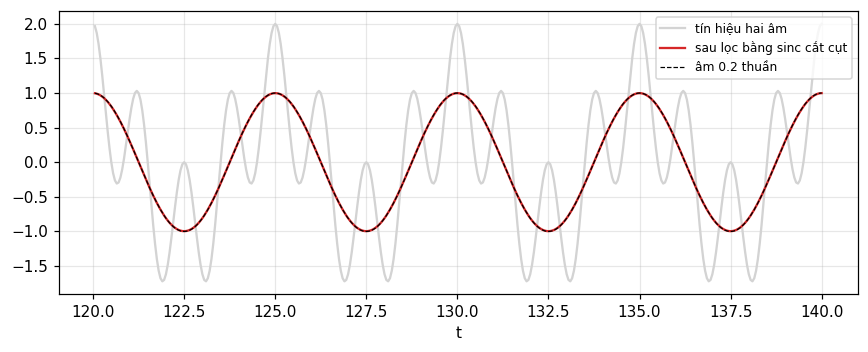

In [9]:
plt.figure(figsize=(8, 3.3))
plt.plot(T[mid][:400], sig[mid][:400], color="lightgray", label=("tín hiệu hai âm"))
plt.plot(T[mid][:400], ya[mid][:400], "tab:red", label=("sau lọc bằng sinc cắt cụt"))
plt.plot(T[mid][:400], np.cos(2*np.pi*0.2*T[mid][:400]), "k--", lw=0.8, label=("âm 0.2 thuần"))
plt.xlabel("t"); plt.legend(loc="upper right", fontsize=8); plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
$\text{sinc}(3)$ = 0, $\int_0^{100}\text{sinc}$ = 0.499 (tiến về ½), và $\int_{-1/2}^{1/2}e^{i2\pi s(0.3)}ds$ = 0.8584. Lọc bằng sinc cắt cụt giữ 0.998 tại 0.2 và còn 0.001 tại 0.8; bộ lọc vuông góc qua FFT cho 1 và 0.001. $H*\text{sinc}$ đạt cực đại 1.0895. $\text{sinc}^2(0.5)$ = 0.4053, diện tích 1. Jinc có giá trị trung tâm 0.7854 và điểm không đầu tại 1.2197.

## 5. Cặp biến đổi, cửa sổ, khe quét và trung bình trượt
🎯 **Phương pháp này trả lời câu hỏi gì?** Các cặp biến đổi của các hàm vừa học có đúng, ba cửa sổ khác nhau cho thùy phụ ra sao, khe quét làm suy giảm âm thế nào, và nhân Dirichlet khác sinc bao nhiêu? Ta so tích phân số với công thức, tìm cực đại bằng quét lưới và bằng nghiệm $\tan\pi s=\pi s$, và tích chập số với công thức sinc.

In [10]:
def ft_support(f, a, b, s, pts=None):
    re = integrate.quad(lambda x: f(x)*np.cos(2*np.pi*x*s), a, b, points=pts, limit=400)[0]
    im = integrate.quad(lambda x: -f(x)*np.sin(2*np.pi*x*s), a, b, points=pts, limit=400)[0]
    return re + 1j*im
s3 = 0.3
pairs = [("p_pi_03", ft_support(lambda x: 1.0, -0.5, 0.5, s3), np.sinc(s3)),
         ("p_tri_03", ft_support(lambda x: 1 - abs(x), -1, 1, s3, [0]), np.sinc(s3)**2),
         ("p_g_03", ft_support(g, -10, 10, s3), np.exp(-np.pi*s3**2)),
         ("p_exp_03", ft_support(lambda x: np.exp(-abs(x)), -40, 40, s3, [0]), 2/(1 + 4*np.pi**2*s3**2))]
for key, num_, ex_ in pairs:
    assert abs(num_ - ex_) < 1e-8
    report(key, num_.real, ".4f")
cz = ft_support(lambda x: np.exp(-x), 0, 40, s3)
assert abs(cz - 1/(1 + 2j*np.pi*s3)) < 1e-8
report("p_caus_03", abs(cz), ".4f"); report("pairs_ok", 5, "d")

# Thùy phụ đầu: cách A quét lưới; cách B nghiệm của tan(πs) = πs
ss = np.arange(1, 3, 1e-5)
peak_scan = np.max(np.abs(np.sinc(ss)))
s_root = optimize.brentq(lambda s: np.tan(np.pi*s) - np.pi*s, 1.3, 1.5)
peak_root = abs(np.sinc(s_root))
assert abs(peak_scan - peak_root) < 1e-8
report("sl_rect", peak_root, ".4f"); report("sl_rect_db", 20*np.log10(peak_root), ".2f")
report("sl_tri", peak_root**2, ".4f"); report("sl_tri_db", 20*np.log10(peak_root**2), ".2f")

# Khe quét: tích chập số so với sinc(w f0)
dxk = 0.001; xt = np.arange(0, 20, dxk); track = np.cos(2*np.pi*1.0*xt)
for w, key in ((0.25, "slit_025"), (0.5, "slit_05"), (1.0, "slit_1")):
    ker = np.ones(int(round(w/dxk)))/int(round(w/dxk))
    out = np.convolve(track, ker, "valid")
    xo = xt[:len(out)]
    A = np.column_stack([np.cos(2*np.pi*xo), np.sin(2*np.pi*xo)])
    co = np.linalg.lstsq(A, out, rcond=None)[0]
    amp = np.hypot(*co)
    assert abs(amp - abs(np.sinc(w*1.0))) < 5e-3
    report(key, abs(np.sinc(w)), ".4f")

# Trung bình trượt 8 điểm: freqz so với công thức, và xấp xỉ sinc
from scipy import signal
fE = 0.05
_, Hm = signal.freqz(np.ones(8)/8, worN=[2*np.pi*fE])
exact_ma = abs(np.sin(np.pi*8*fE)/(8*np.sin(np.pi*fE)))
assert abs(abs(Hm[0]) - exact_ma) < 1e-12
report("ma_exact", exact_ma, ".4f"); report("ma_sinc", abs(np.sinc(8*fE)), ".4f")

▸ p_pi_03 = 0.8584
▸ p_tri_03 = 0.7368
▸ p_g_03 = 0.7537
▸ p_exp_03 = 0.4393
▸ p_caus_03 = 0.4686
▸ pairs_ok = 5
▸ sl_rect = 0.2172
▸ sl_rect_db = -13.26
▸ sl_tri = 0.0472
▸ sl_tri_db = -26.52
▸ slit_025 = 0.9003
▸ slit_05 = 0.6366
▸ slit_1 = 0


▸ ma_exact = 0.7599
▸ ma_sinc = 0.7568


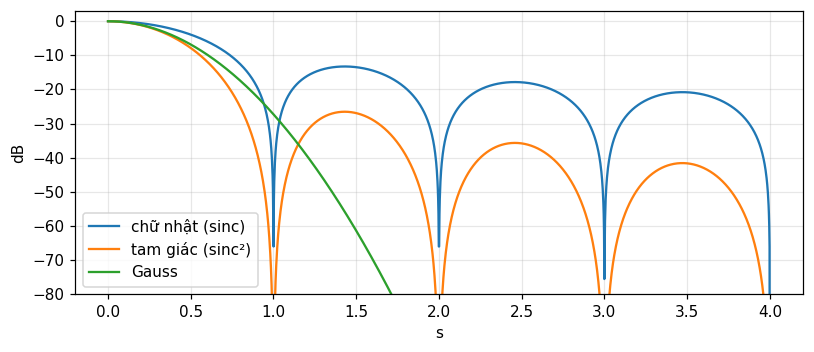

In [11]:
sf = np.linspace(0, 4, 2000)
plt.figure(figsize=(7.5, 3.3))
plt.plot(sf, 20*np.log10(np.abs(np.sinc(sf)) + 1e-12), label=("chữ nhật (sinc)"))
plt.plot(sf, 20*np.log10(np.sinc(sf)**2 + 1e-12), label=("tam giác (sinc²)"))
plt.plot(sf, 20*np.log10(np.exp(-np.pi*(sf/1.0)**2) + 1e-12), label=("Gauss"))
plt.ylim(-80, 3); plt.xlabel("s"); plt.ylabel("dB"); plt.legend(); plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
Tại $s=0.3$: $\Pi$ cho 0.8584, $\Lambda$ cho 0.7368, Gauss 0.7537, $e^{-|x|}$ cho 0.4393, $|F|$ của $e^{-x}H$ là 0.4686: 5 trên 5 cặp đúng. Thùy phụ đầu: sinc 0.2172 (-13.26 dB) bằng cả quét lưới lẫn nghiệm $\tan\pi s=\pi s$; sinc$^2$ 0.0472 (-26.52 dB). Khe quét giữ 0.9003, 0.6366, 0 biên độ khi rộng 0.25, 0.5, 1 chu kỳ. Trung bình 8 điểm tại 0.05: chính xác 0.7599, sinc 0.7568.